In [1]:
%%capture
!pip install lightning

## 複雑な目的関数のイメージ

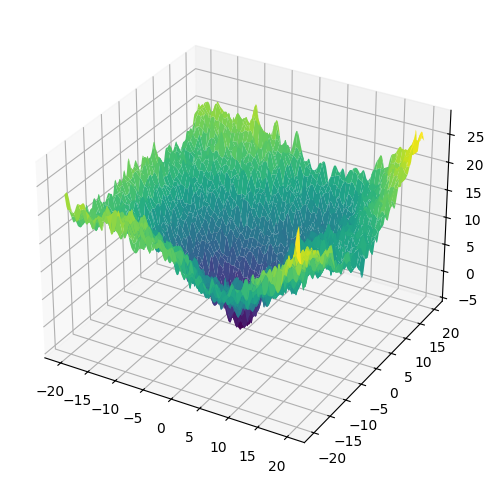

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from mpl_toolkits.mplot3d import Axes3D

# パラメータ設定
A = 5        # クレーターの深さ
sigma = 3    # クレーターの広がり
B = 0.8      # 傾斜の強さ
C = 6.0      # ノイズの強さ
D = 4        # うねりの強さ
alpha = 0.2  # うねりの周波数
flatten_scale = 1  # 縦方向スケーリング
noise_smooth = 1.8   # ノイズの平滑度（大きいと低周波）

# 格子状のx, y座標
x = np.linspace(-20, 20, 200)
y = np.linspace(-20, 20, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# ノイズ生成 + 平滑化で周波数構造を加える
np.random.seed(0)
raw_noise = np.random.normal(scale=1.0, size=R.shape)
structured_noise = gaussian_filter(raw_noise, sigma=noise_smooth)

# 地形関数（D項追加 & 高さ圧縮）
Z = (
    -A * np.exp(-R**2 / (2 * sigma**2)) + 
    B * R +
    C * structured_noise +  # 空間的構造を持つノイズ
    D * np.sin(alpha * X) * np.cos(alpha * Y)
)
Z *= flatten_scale

# 描画
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_zlim(Z.min(), Z.max())
plt.show()

## 過剰パラメーターでの学習過程の可視化

In [ ]:
# =========================================
# Loss Landscape Recorder  (Lightning)
# =========================================
# 依存ライブラリ（Colab なら最初に一度だけ）
# -----------------------------------------
import os, time, numpy as np, torch, lightning as L, torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils import parameters_to_vector, vector_to_parameters

plt.rcParams["figure.figsize"] = (7, 6)

# ----------------------------
# XOR データ  (Tensor 化は一度だけ)
# ----------------------------
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
Y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)
loader = DataLoader(TensorDataset(X, Y), batch_size=4, shuffle=False)

# ----------------------------
# 0. Tracker (固定フレーム)
# ----------------------------
class LossTracker2D:
    def __init__(self, model, span=1.0, grid=41):
        self.model = model
        self.crit  = model.crit
        self.span  = span; self.grid = grid

        self.w0 = parameters_to_vector(model.parameters()).detach()
        self.d1, self.d2 = self._random_dirs(self.w0)
        self.d1_sq, self.d2_sq = (self.d1 @ self.d1), (self.d2 @ self.d2)

        a = np.linspace(-span, span, grid, dtype=np.float32)
        self.A, self.B = np.meshgrid(a, a)

    def _random_dirs(self, w):
        d1 = torch.randn_like(w); d1 /= d1.norm()
        d2 = torch.randn_like(w) - (torch.randn_like(w) @ d1) * d1
        d2 /= d2.norm()
        return d1 * w.norm(), d2 * w.norm()

    @torch.no_grad()
    def _surface(self, center_vec):
        Z = np.zeros_like(self.A)
        backup = parameters_to_vector(self.model.parameters()).detach()
        for i in range(self.grid):
            for j in range(self.grid):
                vec = center_vec + self.A[j,i]*self.d1 + self.B[j,i]*self.d2
                vector_to_parameters(vec, self.model.parameters())
                Z[j,i] = self.crit(self.model(X), Y).item()
        vector_to_parameters(backup, self.model.parameters())
        return Z

    # ---- 公開 API ----
    def initial_surface(self):           return self._surface(self.w0)
    def find_coordinates(self, model):
        delta = parameters_to_vector(model.parameters()).detach() - self.w0
        alpha = (delta @ self.d1) / self.d1_sq
        beta  = (delta @ self.d2) / self.d2_sq
        return float(alpha), float(beta)
    def recompute_loss_surface(self, model):
        center = parameters_to_vector(model.parameters()).detach()
        return self._surface(center)

class LandscapeRecorder(L.Callback):
    """Collect α-β coordinates & loss-surface grids during training."""

    def __init__(
        self,
        tracker: LossTracker2D,
        record_every: int = 20,
        out_dir: str | None = None,          # ← NEW (absolute or relative)
    ):
        """
        Parameters
        ----------
        tracker       : the fixed-frame LossTracker2D instance
        record_every  : how many training steps to skip between snapshots
        out_dir       : path of the folder where .npy files go.
                        • If None  →  auto-timestamp folder under 'cache/'.
                        • If a path that already exists, snapshots append there.
        """
        super().__init__()
        if out_dir is None:
            ts = time.strftime("%Y%m%d-%H%M%S")
            out_dir = os.path.join("cache", f"loss_anim_{ts}")
        os.makedirs(out_dir, exist_ok=True)

        self.dir     = out_dir
        self.tracker = tracker
        self.every   = record_every

        # ---- save the static grid right away ----
        np.save(os.path.join(self.dir, "grid_A.npy"), tracker.A)
        np.save(os.path.join(self.dir, "grid_B.npy"), tracker.B)
        np.save(os.path.join(self.dir, "surf_000.npy"), tracker.initial_surface())
        np.save(os.path.join(self.dir, "coord.npy"),
                np.array([[0.0, 0.0]], dtype=np.float32))

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch
        last  = epoch == trainer.max_epochs - 1
        every = (epoch % self.every == 0)

        if not every and not last:
            return

        # ---- append coord ----
        coord = np.load(os.path.join(self.dir, "coord.npy"))
        a, b  = self.tracker.find_coordinates(pl_module)
        coord = np.vstack([coord, [a, b]])
        np.save(os.path.join(self.dir, "coord.npy"), coord)

        # ---- save surface ----
        surf = self.tracker.recompute_loss_surface(pl_module)
        np.save(os.path.join(self.dir, f"surf_{epoch:03d}.npy"), surf)
# ----------------------------
# 2. LightningModel
# ----------------------------
class XORNet(L.LightningModule):
    def __init__(self, hidden=8, lr=0.05):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1))
        self.crit = nn.BCEWithLogitsLoss(); self.lr = lr
    def forward(self,x): return self.model(x)
    def training_step(self,b,_): return {"loss": self.crit(self(b[0]), b[1])}
    def configure_optimizers(self): return torch.optim.SGD(self.parameters(), lr=self.lr)


In [19]:
from IPython.display import HTML
from matplotlib import animation
import matplotlib.pyplot as plt
import numpy as np
import os, glob, re

class LandscapeAnimator:
    # -------- constructor stays identical --------
    def __init__(self, directory: str):
        self.dir = directory
        self.A = np.load(os.path.join(directory, "grid_A.npy"))
        self.B = np.load(os.path.join(directory, "grid_B.npy"))
        self.surfs = sorted(
            glob.glob(os.path.join(directory, "surf_*.npy")),
            key=lambda f: int(re.findall(r"\d+", os.path.basename(f))[0]),
        )
        self.surfs = [np.load(f) for f in self.surfs]
        self.coords = np.load(os.path.join(directory, "coord.npy"))

    # =============================================================
    #  LOW-LEVEL helper – used by both show_frame() & animate()
    # =============================================================
    def _draw_frame(
        self,
        ax,
        idx,
        *,
        alpha=1.0,
        ball_radius_factor: float = 0.02,   # ← NEW
        **surf_kwargs,
    ):
        """Draw surface + red ball for frame `idx`."""
        # -- erase old --
        for art in getattr(ax, "_artists", []):
            art.remove()
        ax._artists = []

        # -- new surface --
        Z = self.surfs[idx]
        a, b = self.coords[idx]
        surf = ax.plot_surface(
            self.A, self.B, Z,
            alpha=alpha, cmap="viridis",
            linewidth=0, antialiased=False,
            **surf_kwargs,
        )

        # loss height at (a,b)
        ia = np.abs(self.A[0] - a).argmin()
        ib = np.abs(self.B[:, 0] - b).argmin()
        z  = Z[ib, ia]

        # radius in data-coords (fraction of z-span)
        zmin, zmax = ax.get_zlim()
        r = ball_radius_factor * (zmax - zmin)

        point = ax.scatter([a], [b], [z + r], c="red", s=60)

        ax._artists.extend([surf, point])
        ax._point = point
        return [surf, point]

    # ======= single static figure =======
    def show_frame(
        self,
        idx: int = -1,
        *,
        elev: float = 30,
        azim: float = -60,
        alpha: float = 1.0,
        xlim=None,
        ylim=None,
        zlim=None,
        **surf_kwargs,
    ):
        idx %= len(self.surfs)  # wrap
        fig = plt.figure(figsize=(7, 6))
        ax = fig.add_subplot(111, projection="3d")
        self._draw_frame(ax, idx, alpha=alpha, **surf_kwargs)

        ax.set_xlabel(r"$\alpha$")
        ax.set_ylabel(r"$\beta$")
        ax.set_zlabel("Loss")
        ax.set_title(f"Frame {idx}")
        ax.view_init(elev=elev, azim=azim)
        if xlim: ax.set_xlim(*xlim)
        if ylim: ax.set_ylim(*ylim)
        if zlim: ax.set_zlim(*zlim)
        plt.tight_layout()
        plt.show()
        return fig, ax  # so user can further tweak if wanted

    # ======= HTML5 animation =======
    def animate(
        self,
        *,
        interval: int = 200,
        elev: float = 30,
        azim: float = -60,
        alpha: float = 1.0,
        xlim=None,
        ylim=None,
        zlim=None,
        show: bool = True,
        savefile: str | None = None,
        **surf_kwargs,
    ):
        """
        interval   : ms between frames
        elev/azim  : camera angles
        alpha      : surface transparency
        xlim/ylim/zlim : optional axis limits (tuple)
        show       : if True, display inline in a notebook (HTML5 video)
        savefile   : optional path to .mp4 / .gif
        **surf_kwargs : forwarded to plot_surface (e.g. cmap, linewidth…)
        """
        fig = plt.figure(figsize=(7, 6))
        ax = fig.add_subplot(111, projection="3d")
        ax.set_xlabel(r"$\alpha$")
        ax.set_ylabel(r"$\beta$")
        ax.set_zlabel("Loss")
        ax.view_init(elev=elev, azim=azim)

        # apply user axis limits once
        if xlim: ax.set_xlim(*xlim)
        if ylim: ax.set_ylim(*ylim)
        if zlim: ax.set_zlim(*zlim)

        # draw first frame
        self._draw_frame(ax, 0, alpha=alpha, **surf_kwargs)

        def update(frame):
            self._draw_frame(ax, frame, alpha=alpha, **surf_kwargs)
            return ax.collections + [ax._point]

        anim = animation.FuncAnimation(
            fig, update, frames=len(self.surfs), interval=interval, blit=False
        )

        if savefile:
            ext = os.path.splitext(savefile)[1].lower()
            if ext == ".gif":
                anim.save(savefile, writer="pillow", fps=1000 // interval)
            else:  # mp4 & others via ffmpeg
                anim.save(savefile, writer="ffmpeg")
            print("Saved:", savefile)

        if show:
            from IPython.display import HTML
            html = HTML(anim.to_jshtml())
            plt.close(fig)
            return html
        return anim

In [20]:
from IPython.display import display
from dataclasses import dataclass

@dataclass
class Result:
    name: str
    animator: LandscapeAnimator

# ----------------------------
# 3. 学習 & 情報保存
# ----------------------------
results = []
for hidden_dim in [2, 4, 8, 16, 32]:
    print(f"Animation for hidden_dim = {hidden_dim}...")
    # ----------------------------
    # 再現性
    # ----------------------------
    torch.manual_seed(0); np.random.seed(0)

    model   = XORNet(hidden=hidden_dim, lr=0.05)
    tracker = LossTracker2D(model, span=1.0, grid=41)
    rec_cb  = LandscapeRecorder(tracker, record_every=20, out_dir=f"cache/loss_anim_hidden={hidden_dim}")

    trainer = L.Trainer(max_epochs=300, logger=False,
                        enable_progress_bar=False,
                        callbacks=[rec_cb], deterministic=True)
    trainer.fit(model, loader)

    print(f"\nAnimation data saved to:  {rec_cb.dir}")

    # Show all recorded frames with specific view angles
    animator = LandscapeAnimator(rec_cb.dir)
    results.append(Result(f"hidden={hidden_dim}", animator))

Animation for hidden_dim = 2...


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /Users/teshima/lecture-supplement-material/Introduction-to-AI/checkpoints exists and is not empty.

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | Sequential        | 21     | train
1 | crit  | BCEWithLogitsLoss | 0      | train
----------------------------------------------------
21        Trainable params
0         Non-trainable params
21        Total params
0.000     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
/Users/teshima/lectu


Animation data saved to:  cache/loss_anim_hidden=2
Animation for hidden_dim = 4...


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | Sequential        | 57     | train
1 | crit  | BCEWithLogitsLoss | 0      | train
----------------------------------------------------
57        Trainable params
0         Non-trainable params
57        Total params
0.000     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_epochs=300` reached.



Animation data saved to:  cache/loss_anim_hidden=4
Animation for hidden_dim = 8...


...


Animation data saved to:  cache/loss_anim_hidden=8
Animation for hidden_dim = 16...


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | Sequential        | 609    | train
1 | crit  | BCEWithLogitsLoss | 0      | train
----------------------------------------------------
609       Trainable params
0         Non-trainable params
609       Total params
0.002     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_epochs=300` reached.



Animation data saved to:  cache/loss_anim_hidden=16
Animation for hidden_dim = 32...


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | Sequential        | 2.2 K  | train
1 | crit  | BCEWithLogitsLoss | 0      | train
----------------------------------------------------
2.2 K     Trainable params
0         Non-trainable params
2.2 K     Total params
0.009     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_epochs=300` reached.



Animation data saved to:  cache/loss_anim_hidden=32


In [21]:
plot_kwargs = dict(
    elev=0,   # Set a good elevation angle for visualization
    azim=-60,  # Set viewing angle 
    alpha=0.2,  # Make surface slightly transparent
    # zlim=(.675, .7),  # Set z-axis limits
)

In [22]:
# ----------------------------
# 4. アニメーション表示
# ----------------------------

for result in results:
    print(result.name)
    animator = result.animator
    n_frames = len(animator.surfs)
    print(f"Showing all {n_frames} frames of the loss landscape...")

    # 1️⃣  just a static frame
    # for i in range(n_frames):
    #     # Create subplot with consistent view
    #     animator.show_frame(
    #         idx=i, **kwargs
    #     )

    # 2️⃣  inline animation (HTML5) — reuses the same drawing code
    html_anim = animator.animate(interval=150, show=True, **plot_kwargs)
    display(html_anim)

hidden=2
Showing all 16 frames of the loss landscape...


hidden=4
Showing all 16 frames of the loss landscape...


hidden=8
Showing all 16 frames of the loss landscape...


hidden=16
Showing all 16 frames of the loss landscape...


hidden=32
Showing all 16 frames of the loss landscape...


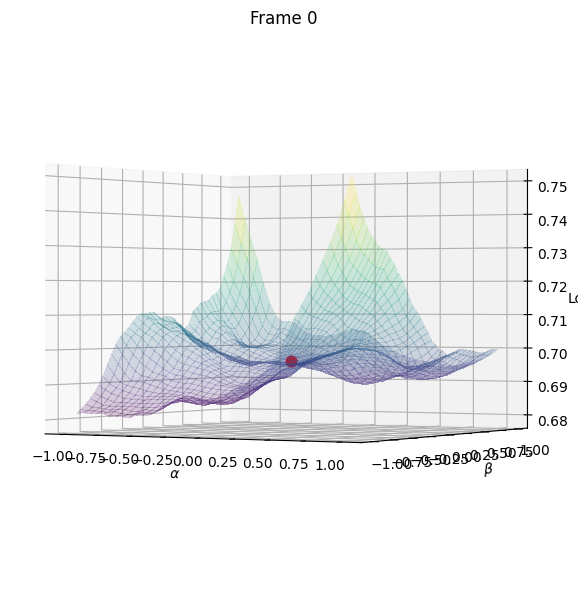

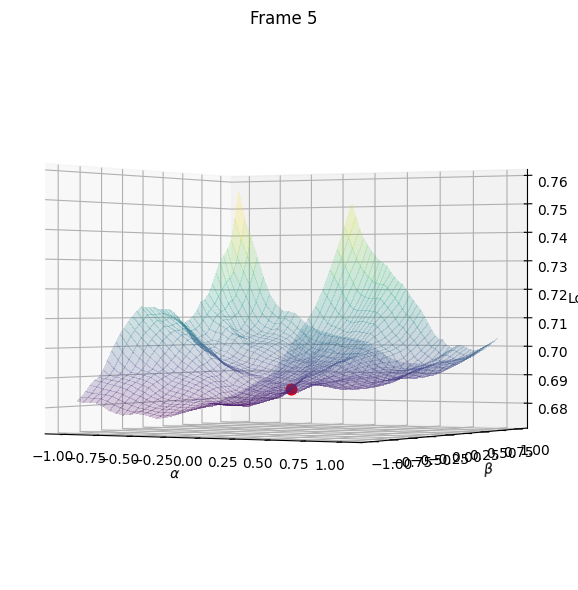

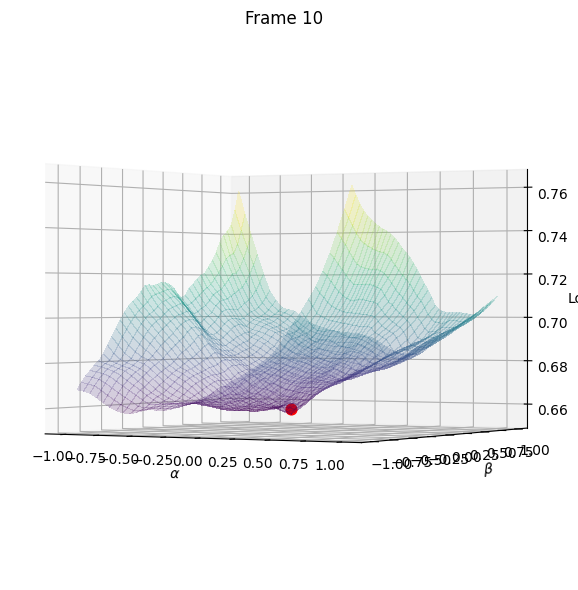

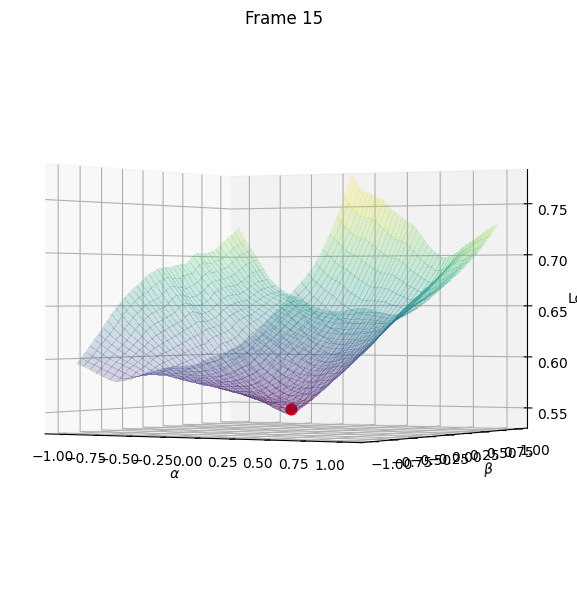

(<Figure size 700x600 with 1 Axes>,
 <Axes3D: title={'center': 'Frame 15'}, xlabel='$\\alpha$', ylabel='$\\beta$', zlabel='Loss'>)

In [23]:
result = [result for result in results if result.name == "hidden=32"][0]
result.animator.show_frame(idx=0, **plot_kwargs)
result.animator.show_frame(idx=5, **plot_kwargs)
result.animator.show_frame(idx=10, **plot_kwargs)
result.animator.show_frame(**plot_kwargs)